In [1]:
print('hello')
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.pyplot import rc_context

h5ad_file = "/home/catherine/phd/projects/termites/data/znev/combined_no_norm_clustered.h5ad"
adata = sc.read_h5ad(h5ad_file)


hello


In [2]:
# Load the Excel file

caz = pd.read_csv('/home/catherine/phd/projects/termites/code/znev_analysis/cazymes_investigation/Znev_cazyme/Znev_cazyme/Znev.tsv', sep='\t')
import scanpy as sc
import pandas as pd

# Step 1: Trim the last three characters from 'TranscriptID'
caz['Trimmed_TranscriptID'] = caz['TranscriptID'].str[:-3]

# Step 2: Filter transcript IDs that exist in adata.var_names
matching_transcripts = caz[caz['Trimmed_TranscriptID'].isin(adata.var_names)]

# Step 3: Create a dictionary mapping CAZymes to transcript IDs
cazymes_dict = matching_transcripts.groupby('CAZymes')['Trimmed_TranscriptID'].apply(list).to_dict()


Malpighian tubule stellate


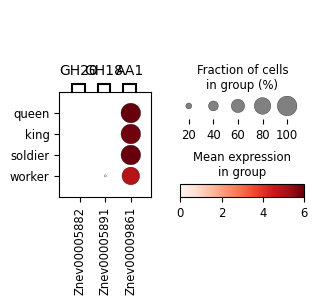

cardiac cell


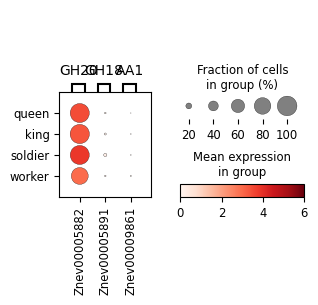

excretory


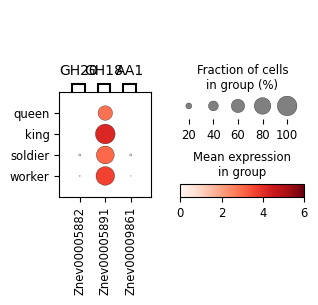

T3


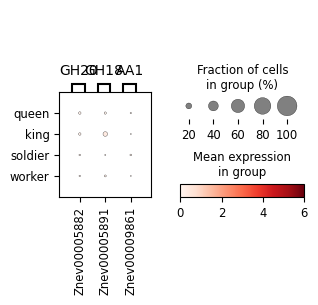

hemocyte


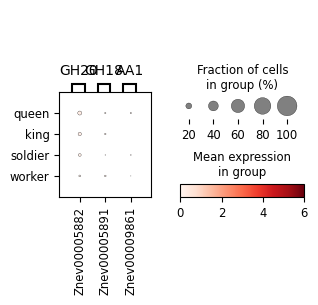

glial cell


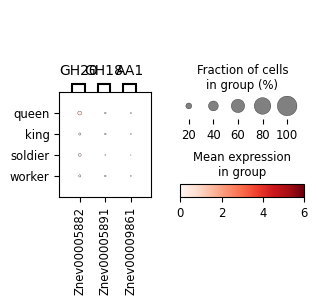

T4


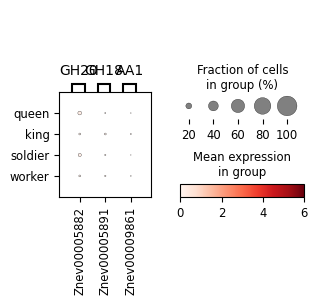

T2


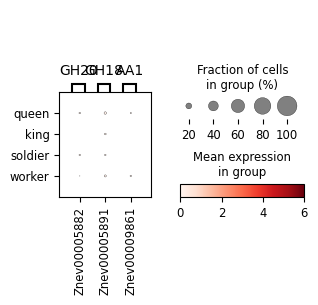

neuron


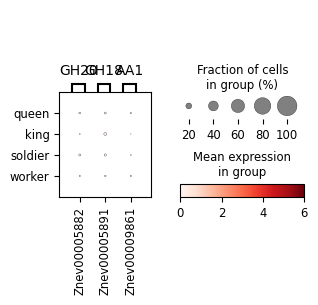

T6


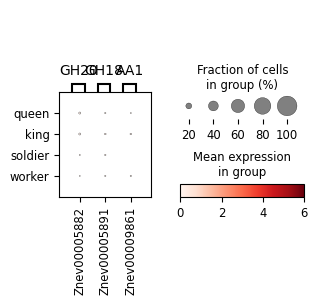

epithelial


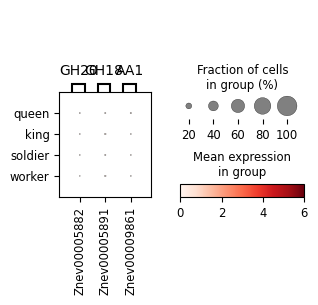

T5


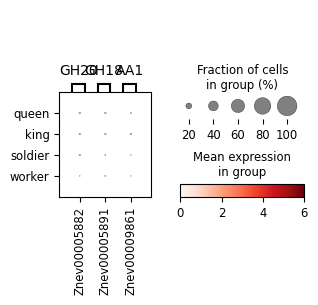

muscle cell


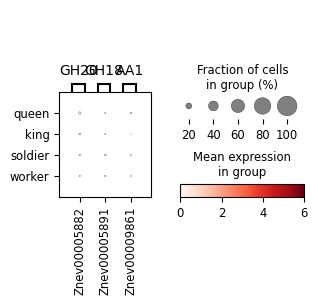

gustatory neuron


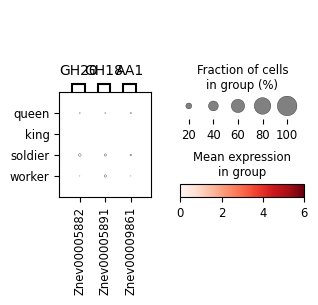

oenocyte


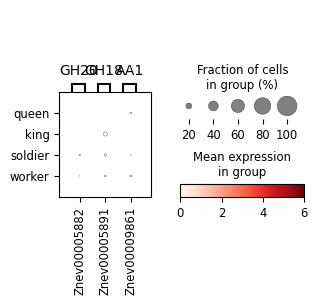

stem cell


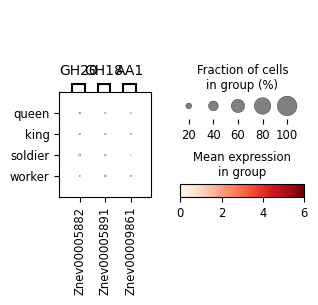

sensory neuron


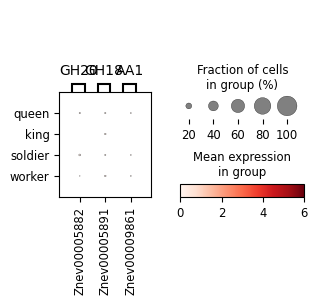

crystal cell


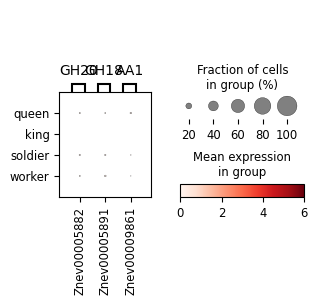

intestinal progenitor like


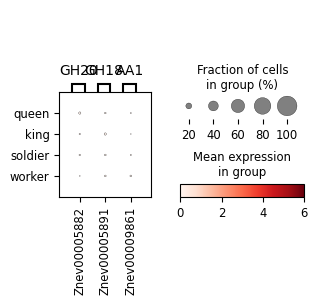

fat cell


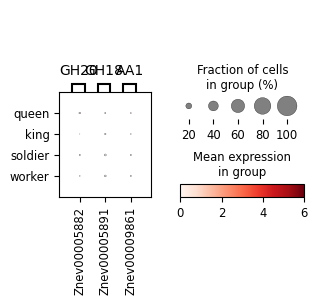

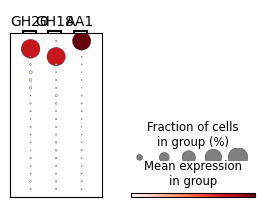

In [3]:
import os
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scanpy as sc
import matplotlib.pyplot as plt

celltype_col = "paper_cell_type_annotation"
caste_col    = "caste"
top_n_genes  = 3
top_k_groups = 20

# =========================
# Step 1: Trim & match var_names
# =========================
caz = caz.copy()
caz["Trimmed_TranscriptID"] = caz["TranscriptID"].str[:-3]
matching = caz[caz["Trimmed_TranscriptID"].isin(adata.var_names)]
genes = matching["Trimmed_TranscriptID"].values

# =========================
# Step 2: Global means per cell type
# =========================
X = adata[:, genes].X
celltypes = adata.obs[celltype_col].astype("category")
ct_cats = celltypes.cat.categories

ct_means = pd.DataFrame(index=genes, columns=ct_cats, dtype=float)
for ct in ct_cats:
    mask = (celltypes == ct).values
    Xg = X[mask]
    means = np.asarray(Xg.mean(axis=0)).ravel() if sp.issparse(Xg) else Xg.mean(axis=0)
    ct_means[ct] = means

gene_scores = ct_means.max(axis=1)
top_genes = gene_scores.nlargest(top_n_genes).index.tolist()

ct_scores = ct_means.loc[top_genes].mean(axis=0)
top_celltypes = ct_scores.sort_values(ascending=False).head(top_k_groups).index.tolist()

top_cazymes_dict = {
    cz: [g for g in gene_list if g in top_genes]
    for cz, gene_list in cazymes_dict.items()
}
top_cazymes_dict = {k: v for k, v in top_cazymes_dict.items() if v}
top_cazymes_dict = dict(reversed(list(top_cazymes_dict.items())))
# =========================
# PLOT SETTINGS
# =========================
FIGSIZE = (2.5, 2.4)
LEFT    = 0
RIGHT   = 0.98
TOP     = 0.90
BOTTOM  = 0.12

os.makedirs("plots", exist_ok=True)

# =========================
# Plot A: one dotplot per CELL TYPE (y = caste)
# =========================
castes_order = ["queen", "king", "soldier", "worker"]
castes_present = [c for c in castes_order if c in adata.obs[caste_col].unique().tolist()]
if len(castes_present) == 0:
    castes_present = adata.obs[caste_col].astype("category").cat.categories.tolist()

for ct in top_celltypes:
    print(ct)

    adata_sub = adata[adata.obs[celltype_col] == ct].copy()

    adata_sub.obs[caste_col] = adata_sub.obs[caste_col].astype("category")
    present_castes = [c for c in castes_present if c in adata_sub.obs[caste_col].unique().tolist()]
    if len(present_castes) == 0:
        print(f"[SKIP] {ct}: no castes present.")
        continue

    adata_sub = adata_sub[adata_sub.obs[caste_col].isin(present_castes)].copy()
    adata_sub.obs[caste_col] = adata_sub.obs[caste_col].cat.remove_unused_categories()
    adata_sub.obs[caste_col] = adata_sub.obs[caste_col].cat.reorder_categories(present_castes, ordered=True)

    # ---- Make dotplot (do NOT rely on return_fig / dp object) ----
    sc.pl.dotplot(
        adata_sub,
        var_names=top_cazymes_dict,
        groupby=caste_col,
        vmin=0,
        vmax=6,
        dot_max=1.0,
        show=False,
        
    )

    # ---- Standardise current figure ----
    fig = plt.gcf()
    fig.set_size_inches(*FIGSIZE, forward=True)
    fig.subplots_adjust(left=LEFT, right=RIGHT, top=TOP, bottom=BOTTOM)

    '''# ---- Remove ALL ticks + labels on ALL axes in this figure ----
    for ax in fig.axes:
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(axis="x", which="both", length=0)
    
    # remove category labels (CAZyme group labels)
    if len(fig.axes) > 1:
        fig.axes[1].set_visible(False)'''

    # ---- Save ----
    fig.savefig(
        f"plots/cazyme_dotplot_castes_{ct}.png",
        dpi=600,
        bbox_inches="tight"
    )
    plt.show()

    plt.close(fig)

# =========================
# Plot B: one dotplot for ALL selected CELL TYPES (y = cell type)
# =========================
adata_all_ct = adata[adata.obs[celltype_col].isin(top_celltypes)].copy()
adata_all_ct.obs[celltype_col] = adata_all_ct.obs[celltype_col].astype("category")
adata_all_ct.obs[celltype_col] = adata_all_ct.obs[celltype_col].cat.remove_unused_categories()
adata_all_ct.obs[celltype_col] = adata_all_ct.obs[celltype_col].cat.reorder_categories(top_celltypes, ordered=True)

sc.pl.dotplot(
    adata_all_ct,
    var_names=top_cazymes_dict,
    groupby=celltype_col,
    vmin=0,
    vmax=4.5,
    #dot_max=1.0,
    show=False
)

fig = plt.gcf()
fig.set_size_inches(*FIGSIZE, forward=True)
fig.subplots_adjust(left=LEFT, right=RIGHT, top=TOP, bottom=BOTTOM)

for ax in fig.axes:
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="both", which="both", length=0)

fig.savefig(
    "plots/cazyme_dotplot_all_celltypes.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()
plt.close(fig)

worker
soldier
king
queen


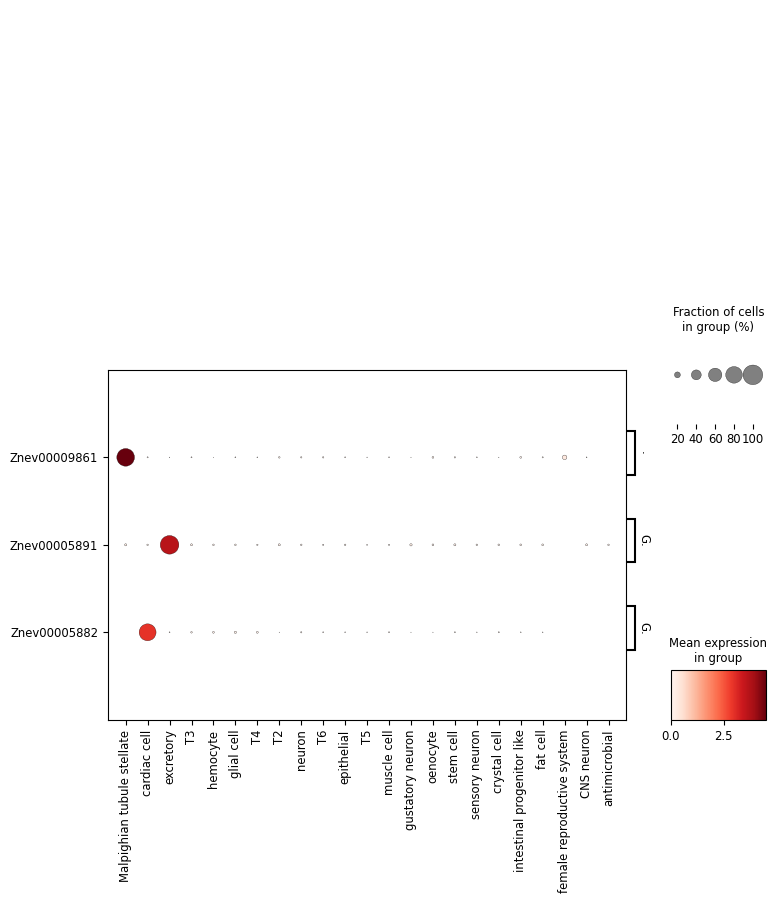

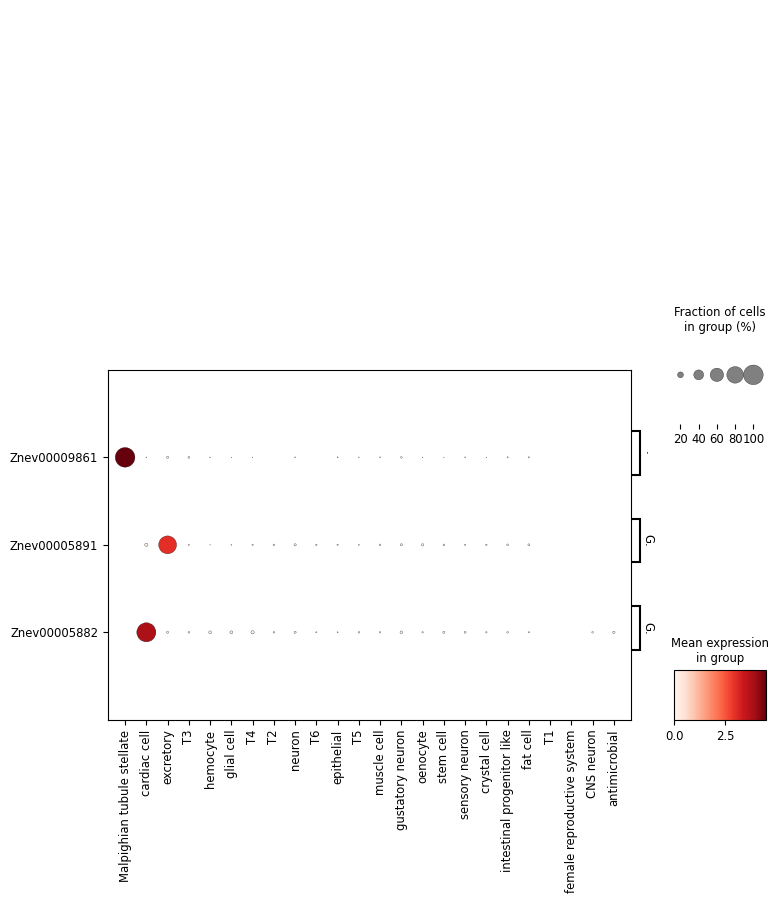

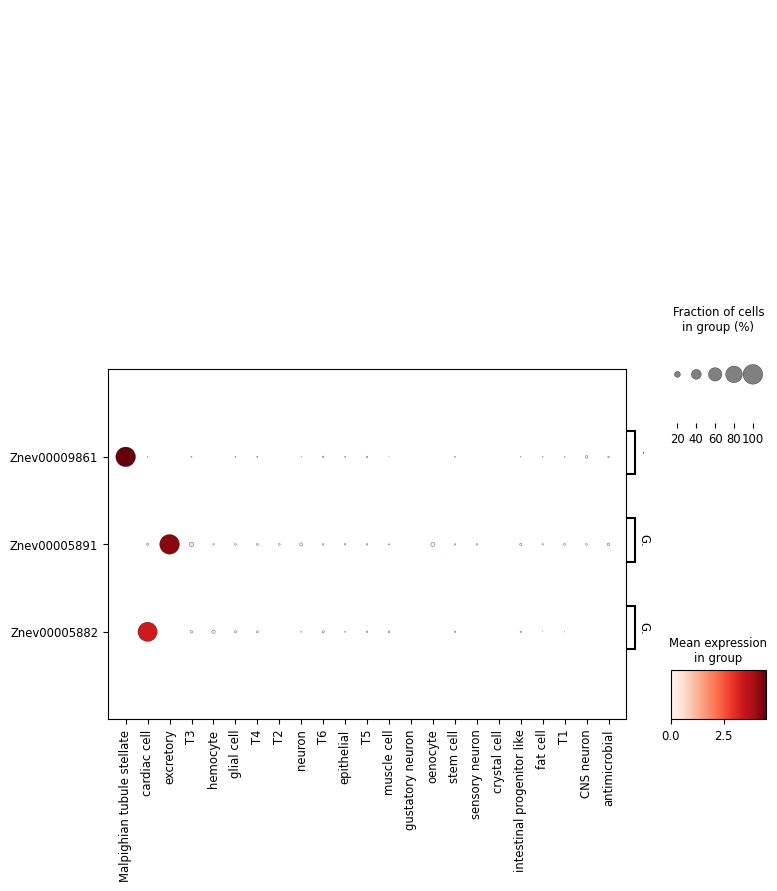

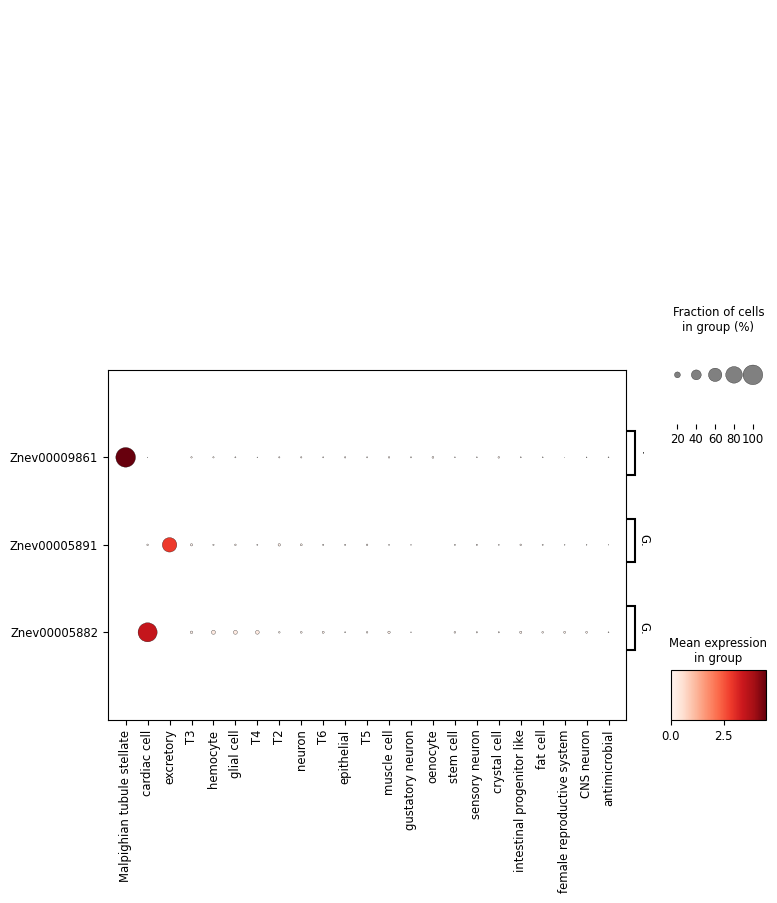

In [4]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scanpy as sc
import matplotlib.pyplot as plt

celltype_col = "paper_cell_type_annotation"
caste_col    = "caste"
top_n_genes  = 3
top_k_groups = 33
caste_order  = ["worker", "soldier", "king", "queen"]  # change if needed

# ---------- helper to force consistent figure size + left margin ----------
def _standardise_dotplot(dp, figsize=(10, 6), left=0.28, right=0.98, top=0.90, bottom=0.12):
    """
    Make dotplot figures the same size and reserve a fixed left margin for y tick labels,
    so label-length differences don't change plot size.
    """
    try:
        fig = dp.fig
    except Exception:
        fig = plt.gcf()

    fig.set_size_inches(*figsize, forward=True)
    fig.subplots_adjust(left=left, right=right, top=top, bottom=bottom)
    return fig

# =========================
# Step 1: Trim & match var_names
# =========================
caz = caz.copy()
caz["Trimmed_TranscriptID"] = caz["TranscriptID"].str[:-3]
matching = caz[caz["Trimmed_TranscriptID"].isin(adata.var_names)]
genes = matching["Trimmed_TranscriptID"].values

# =========================
# Step 2: Global means per cell type (for selecting genes/cell types)
#         (kept GLOBAL so the same genes/cell types are used in every caste plot)
# =========================
X = adata[:, genes].X
celltypes = adata.obs[celltype_col].astype("category")
ct_cats = celltypes.cat.categories

ct_means = pd.DataFrame(index=genes, columns=ct_cats, dtype=float)
for ct in ct_cats:
    mask = (celltypes == ct).values
    Xg = X[mask]
    means = np.asarray(Xg.mean(axis=0)).ravel() if sp.issparse(Xg) else Xg.mean(axis=0)
    ct_means[ct] = means

gene_scores = ct_means.max(axis=1)
top_genes = gene_scores.nlargest(top_n_genes).index.tolist()

ct_scores = ct_means.loc[top_genes].mean(axis=0)
top_celltypes = ct_scores.sort_values(ascending=False).head(top_k_groups).index.tolist()

top_cazymes_dict = {
    cz: [g for g in gene_list if g in top_genes]
    for cz, gene_list in cazymes_dict.items()
}
top_cazymes_dict = {k: v for k, v in top_cazymes_dict.items() if v}

# =========================
# PLOT SETTINGS (same for ALL plots)
# =========================
FIGSIZE = (9.4, 9.1)  # one setting, applies to every caste plot
LEFT    = 0.28        # reserve space for y labels; increase if labels get cut off

# =========================
# Plot: one dotplot per CASTE (y = selected cell types)
# =========================
for caste in caste_order:
    # subset to caste + selected cell types
    adata_c = adata[
        (adata.obs[caste_col] == caste) &
        (adata.obs[celltype_col].isin(top_celltypes))
    ].copy()

    if adata_c.n_obs == 0:
        print(f"[skip] {caste}: no cells after subsetting")
        continue

    # enforce cell type order within this caste (only those that exist in this caste)
    present_cts = adata_c.obs[celltype_col].astype(str).unique().tolist()
    ct_order_this = [ct for ct in top_celltypes if ct in set(present_cts)]

    if len(ct_order_this) == 0:
        print(f"[skip] {caste}: none of the selected cell types present")
        continue

    adata_c.obs[celltype_col] = pd.Categorical(
        adata_c.obs[celltype_col].astype(str),
        categories=ct_order_this,
        ordered=True
    )

    # (optional) drop gene groups with nothing present in this caste's var_names
    caz_dict_this = {
        k: [g for g in v if g in adata_c.var_names]
        for k, v in top_cazymes_dict.items()
    }
    caz_dict_this = {k: v for k, v in caz_dict_this.items() if v}

    if not caz_dict_this:
        print(f"[skip] {caste}: no selected genes present in adata.var_names")
        continue
    
    print(caste)
    dp = sc.pl.dotplot(
        adata_c,
        var_names=caz_dict_this,
        groupby=celltype_col,
        vmin=0,
        vmax=4.5,
        dot_max=1,
        show=False,
        swap_axes=True,
    )
    _standardise_dotplot(dp, figsize=FIGSIZE, left=LEFT)

    # title
    try:
        dp.fig.suptitle(f"CAZyme dotplot — {caste}", y=0.98)
    except Exception:
        pass

    #dp.show()


In [5]:
print(caz_dict_this)

{'AA1': ['Znev00009861'], 'GH18': ['Znev00005891'], 'GH20': ['Znev00005882']}


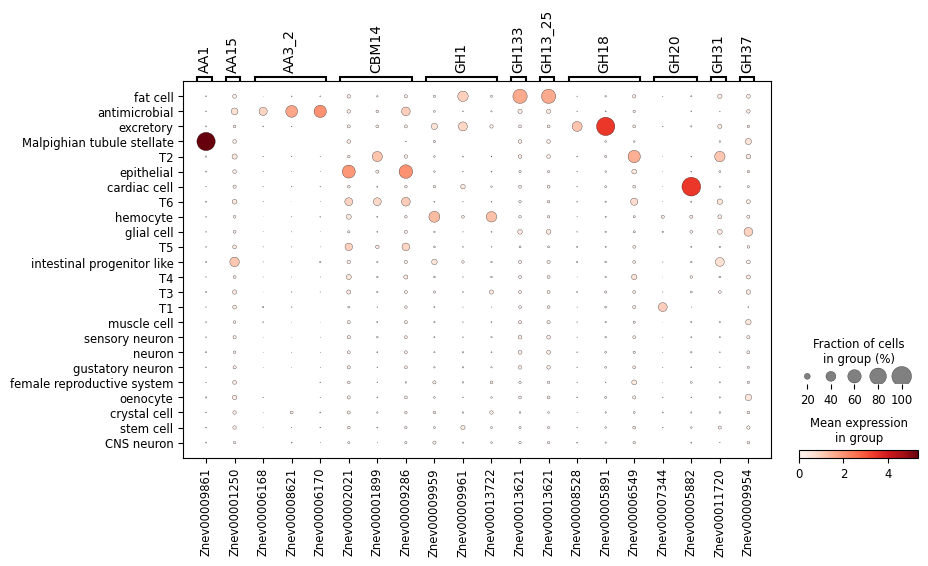

In [6]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scanpy as sc
import matplotlib.pyplot as plt

celltype_col = "paper_cell_type_annotation"
caste_col    = "caste"
top_n_genes  = 20
top_k_groups = 33

# ---------- helper to force consistent figure size + left margin ----------
def _standardise_dotplot(dp, figsize=(10, 6), left=0.28, right=0.98, top=0.90, bottom=0.12):
    """
    Make dotplot figures the same size and reserve a fixed left margin for y tick labels,
    so label-length differences don't change plot size.
    """
    try:
        fig = dp.fig
    except Exception:
        fig = plt.gcf()

    fig.set_size_inches(*figsize, forward=True)
    fig.subplots_adjust(left=left, right=right, top=top, bottom=bottom)
    return fig

# =========================
# Step 1: Trim & match var_names
# =========================
caz = caz.copy()
caz["Trimmed_TranscriptID"] = caz["TranscriptID"].str[:-3]
matching = caz[caz["Trimmed_TranscriptID"].isin(adata.var_names)]
genes = matching["Trimmed_TranscriptID"].values

# =========================
# Step 2: Global means per cell type (for selecting genes/cell types)
# =========================
X = adata[:, genes].X
celltypes = adata.obs[celltype_col].astype("category")
ct_cats = celltypes.cat.categories

ct_means = pd.DataFrame(index=genes, columns=ct_cats, dtype=float)
for ct in ct_cats:
    mask = (celltypes == ct).values
    Xg = X[mask]
    means = np.asarray(Xg.mean(axis=0)).ravel() if sp.issparse(Xg) else Xg.mean(axis=0)
    ct_means[ct] = means

gene_scores = ct_means.max(axis=1)
top_genes = gene_scores.nlargest(top_n_genes).index.tolist()

ct_scores = ct_means.loc[top_genes].mean(axis=0)
top_celltypes = ct_scores.sort_values(ascending=False).head(top_k_groups).index.tolist()

top_cazymes_dict = {
    cz: [g for g in gene_list if g in top_genes]
    for cz, gene_list in cazymes_dict.items()
}
top_cazymes_dict = {k: v for k, v in top_cazymes_dict.items() if v}


# =========================
# PLOT SETTINGS (same for ALL plots)
# =========================
FIGSIZE = (7.5, 5.4)   # <- adjust once, applies to every plot
LEFT    = 0      # <- reserve space for y labels; bigger = more room


# =========================
# Plot B: one dotplot for ALL selected CELL TYPES (y = cell type)
# =========================
adata_all_ct = adata[adata.obs[celltype_col].isin(top_celltypes)].copy()
adata_all_ct.obs[celltype_col] = adata_all_ct.obs[celltype_col].astype("category")
adata_all_ct.obs[celltype_col] = adata_all_ct.obs[celltype_col].cat.remove_unused_categories()
adata_all_ct.obs[celltype_col] = adata_all_ct.obs[celltype_col].cat.reorder_categories(top_celltypes, ordered=True)

dp_all = sc.pl.dotplot(
    adata_all_ct,
    var_names=top_cazymes_dict,
    groupby=celltype_col,
    show=False
)
_standardise_dotplot(dp_all, figsize=FIGSIZE, left=LEFT)

try:
    dp_all.fig.suptitle("CAZyme dotplot — all selected cell types", y=0.98)
except Exception:
    pass
#dp_all.show()


In [9]:
# =========================
# Export Znev ID ↔ CAZyme from top_cazymes_dict
# =========================

rows = []

for cazyme, gene_list in top_cazymes_dict.items():
    for gene in gene_list:
        rows.append({
            "Znev_ID": gene,
            "CAZyme": cazyme
        })

export_df = pd.DataFrame(rows)

export_df.to_csv("top_cazymes_mapping.csv", index=False)

print(export_df.head())
print(f"Exported {len(export_df)} rows")

        Znev_ID CAZyme
0  Znev00009861    AA1
1  Znev00001250   AA15
2  Znev00006168  AA3_2
3  Znev00008621  AA3_2
4  Znev00006170  AA3_2
Exported 20 rows
